<div style="border:solid Chocolate 2px; padding: 40px">
 
<b> Георгий, привет!👋</b> 

Меня зовут Кирилл Васильев, я буду ревьюером твоего проекта. Я предлагаю общаться на «ты», но если привычнее на «вы», просто скажи об этом! 

Я буду оставлять комментарии в твоем проекте. Пожалуйста, не удаляй их, они могут быть полезны в случае повторной проверки.

Свои комментарии я буду обозначать <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:
  
<br/> 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным. Здесь же я могу давать советы и предложения.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div> 
  

<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
 
   
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>  

<br/>
<div class="alerфt alert-info">
Рекомендую для твоих комментариев использовать синий или любой другой цветной фон. Я постараюсь ничего не пропустить, но если комментарии будут выделены, то это мне очень поможет!
</div>
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой руководитель будет поступать также. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.



# Модель предсказания массы морских черепах



- Придумайте тетрадке заголовок, который хорошо описывает решаемую задачу.
- Кратко, но понятно опишите решаемую задачу.

### Описание задачи:
Разработать надёжную модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

### Описание данных:
Данные хранятся в CSV-файле и доступны по ссылке turtles.csv. Они содержат следующие поля:
- id — идентификатор измерения.
- binomial_name — международное научное название вида черепахи.
- registration_number — регистрационный номер черепахи.
- shell_length — длина панциря, мм.
- shell_width — ширина панциря, мм.
- head_length — длина головы, мм.
- head_width — ширина головы, мм.
- flipper_length_n — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- flipper_width_n — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- circle_count — количество колец роста на панцире черепахи.
- measure_count — количество измерений по модели компьютерного зрения перед усреднением показателей.
- shell_crack — наличие трещин панциря.
- timestamp — время внесения данных о черепахе.
- weight — масса черепахи, кг.

## Постановка задачи машинного обучения

- Опишите, какую задачу нужно решить: регрессии или классификации.
    - Регрессии
- Выберите поле, которое станет целевой переменной.
    - weight — масса черепахи, кг.
- Назовите метрики качества модели, которые планируете использовать.
    - В качестве основной будем использовать MAE, дополнительными будут MSE, R², MAPE.
- Опишите критерии успешности проекта с опорой на метрики.
    - MAE не больше 5 килограмм, R² ≥ 0.97 на тестовой выборке, при этом, и другие метрики не должны показывать большую ошибку

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично по описанию. Цели и задачи ясны, обозначены корректно. Контекст проекта будет понятен любому потенциальному читателю.
    
Итак, решаем задачу регрессии.

</div>  

## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [176]:
!pip install phik -q

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Если добавить `-q` к загрузке, то логи выводиться не будут.

`!pip install phik -q`


</div>
  

<br/>
<div class="alerфt alert-info">
         Учтено
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера #2 <a class="tocSkip"> </h2>

👍 Cнова привет. Спасибо за заметное оформление твоих комментариев. По исправлениям отлично.
</div> 


In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
import phik
import scipy.stats as stats

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

In [178]:
turtle_df = pd.read_csv('/datasets/turtles.csv', sep = '\t', decimal = ',')
print(turtle_df.info())
total_memory_usage_old = turtle_df.memory_usage(index=True).sum()
print('-' * 125)
turtle_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511
5,25045,Lepidochelys olivacea,1b076bdf8f9ed92f370f64ffd28b7dd6,341.0,254,54.0,55.0,250,204,240,217,197.0,152.0,185.0,154.0,0,1.0,NaN,1749366080,27.513
6,23228,Lepidochelys olivacea,ad587cf0ebf5ac3a337fc55f91b16086,606.0,526,114.0,91.0,489,407,460,316,440.0,260.0,326.0,300.0,32,2.0,NaN,1731882409,40.228
7,19458,Lepidochelys olivacea,a9d0a18fc14b993b95ea02a314aa4aee,600.0,551,104.0,109.0,411,328,396,338,356.0,258.0,321.0,266.0,20,3.0,NaN,1693572979,38.838
8,25241,Chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
9,20199,Lepidochelys olivacea,baa40598df8e5120e81c65a847a5a5be,399.0,336,NaN,NaN,264,240,288,234,215.0,161.0,226.0,186.0,0,4.0,NaN,1700915750,29.823


In [179]:
turtle_df.describe()

,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
count,8861.000000,8774.000000,8861.000000,8715.000000,8715.000000,8861.000000,8861.000000,8861.000000,8861.000000,8760.000000,8760.000000,8760.000000,8760.000000,8861.000000,8597.000000,2176.000000,8.861000e+03,8842.000000
mean,21359.335628,764.222020,598.832299,123.341021,115.735169,497.551405,380.594515,498.228530,380.687507,397.953196,304.405251,397.853196,305.030023,41.002821,2.477143,1.671415,1.712640e+09,79.163138
std,2263.089420,640.408681,480.970492,67.836566,62.326365,353.575213,214.481679,355.074883,213.485239,282.970532,171.172490,281.983591,171.540535,36.995874,1.116564,1.131790,2.292273e+07,95.877609
min,17438.000000,132.000000,78.000000,19.000000,12.000000,60.000000,34.000000,57.000000,33.000000,50.000000,27.000000,44.000000,25.000000,0.000000,1.000000,1.000000,1.672570e+09,0.000000
25%,19396.000000,440.000000,341.000000,73.000000,67.000000,296.000000,228.000000,296.000000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,1.000000,1.693001e+09,31.109500
50%,21357.000000,635.000000,487.000000,106.000000,98.000000,416.000000,332.000000,417.000000,330.000000,333.000000,264.000000,333.000000,266.000000,35.000000,2.000000,1.000000,1.712804e+09,41.140500
75%,23317.000000,951.000000,794.000000,158.000000,156.000000,571.000000,493.000000,572.000000,500.000000,457.000000,397.000000,456.000000,396.000000,73.000000,3.000000,2.000000,1.732902e+09,85.239500
max,25279.000000,20240.000000,11550.000000,515.000000,382.000000,2875.000000,1479.000000,2967.000000,1402.000000,2279.000000,1280.000000,2406.000000,1313.000000,178.000000,4.000000,5.000000,1.751608e+09,617.777000


Выводы: 
- Название столбца registration number нужно привести к snake_case
- Нужно провести оптимизацию типов данных в числовых столбцах
- Поскольку некоторые величины в полях с габаритами некорректно отображаются, потому что их дополнительно умножили на десять, нужно учесть это на этапе предобработки данных

- Почти во всех столбцах среднее значение превышает медиану, особенно сильно это заметно в признаках shell_length и shell_width. Это говорит о наличии выбросов.
- Данные явно требуют предобработки, но дальнейший анализ и их использование возможно

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Полезно проанализировать данные, используя также метод describe.

    
* есть ли пропуски?
* что у нас с распределениями признаков, можем ли увидеть явные выбросы или нереалистичные значения? 
    
`Сделайте вывод о возможности или невозможности продолжить работу.`



<br/>
<div class="alerфt alert-info">
         Использован метод describe, Добавлены выводы
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера #2 <a class="tocSkip"> </h2>

👍 
</div>
  

In [180]:
turtle_df = turtle_df.rename(columns={'registration number': 'registration_number'})

for i in ['id', 'shell_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'circle_count', 'timestamp']:
    turtle_df[i] = pd.to_numeric(turtle_df[i], downcast = 'integer', errors = 'ignore')
for i in ['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'measure_count', 'shell_crack', 'weight']:
    turtle_df[i] = pd.to_numeric(turtle_df[i], downcast = 'float', errors = 'ignore')
turtle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int16  
 1   binomial_name        8812 non-null   object 
 2   registration_number  8832 non-null   object 
 3   shell_length         8774 non-null   float32
 4   shell_width          8861 non-null   int16  
 5   head_length          8715 non-null   float32
 6   head_width           8715 non-null   float32
 7   flipper_length_1     8861 non-null   int16  
 8   flipper_width_1      8861 non-null   int16  
 9   flipper_length_2     8861 non-null   int16  
 10  flipper_width_2      8861 non-null   int16  
 11  flipper_length_3     8760 non-null   float32
 12  flipper_width_3      8760 non-null   float32
 13  flipper_length_4     8760 non-null   float32
 14  flipper_width_4      8760 non-null   float32
 15  circle_count         8861 non-null   i

In [181]:
total_memory_usage = turtle_df.memory_usage(index=True).sum()
print(f'Промежуточные результаты:\n    Изменили название столбца registration number на registration_number\n    Сократили размерность датасета на {round((total_memory_usage_old - total_memory_usage)/total_memory_usage_old * 100, 2)}%')

Промежуточные результаты:
    Изменили название столбца registration number на registration_number
    Сократили размерность датасета на 53.75%


## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

### Выясним данные о каких черепахах представлены в датасете

In [182]:
print(turtle_df['binomial_name'].unique(), turtle_df['binomial_name'].nunique(), sep = '\n')
print('-' * 60)
print('В названиях черепах наблюдаются дубликаты. Исправим это.')
turtle_df['binomial_name'] = turtle_df['binomial_name'].str.capitalize()
print(turtle_df['binomial_name'].unique(), turtle_df['binomial_name'].nunique(), sep = '\n')

['Caretta caretta' 'Lepidochelys olivacea' 'LEPIDOCHELYS OLIVACEA'
 'Lepidochelys Olivacea' 'lepidochelys olivacea' 'Chelonia mydas'
 'ERETMOCHELYS IMBRICATA' 'Eretmochelys imbricata' 'Dermochelys coriacea'
 'caretta caretta' 'CARETTA CARETTA' 'chelonia mydas' 'Chelonia Mydas'
 'CHELONIA MYDAS' 'Dermochelys Coriacea' 'eretmochelys imbricata' nan
 'Caretta Caretta' 'lepidochelys kempii' 'Lepidochelys kempii'
 'Eretmochelys Imbricata' 'dermochelys coriacea' 'Lepidochelys Kempii'
 'DERMOCHELYS CORIACEA']
23
------------------------------------------------------------
В названиях черепах наблюдаются дубликаты. Исправим это.
['Caretta caretta' 'Lepidochelys olivacea' 'Chelonia mydas'
 'Eretmochelys imbricata' 'Dermochelys coriacea' nan 'Lepidochelys kempii']
6


In [183]:
df = turtle_df['binomial_name'].value_counts().reset_index()
df = df.rename(columns= {'index': 'binomial_name', 'binomial_name': 'counts'})
df

,binomial_name,counts
0,Lepidochelys olivacea,4215
1,Chelonia mydas,2829
2,Caretta caretta,847
3,Dermochelys coriacea,484
4,Eretmochelys imbricata,409
5,Lepidochelys kempii,28


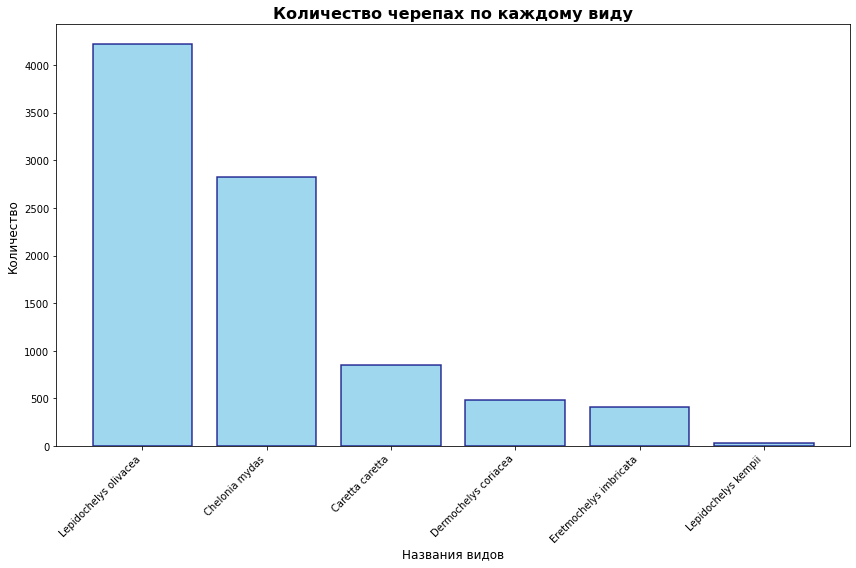

In [184]:
plt.figure(figsize=(12, 8)) 

plt.bar(df['binomial_name'], 
        df['counts'],
        color=['skyblue', 'red'],        
        edgecolor='navy',       
        linewidth=1.5,          
        alpha=0.8)             

plt.title('Распределение классов', fontsize=16, fontweight='bold')
plt.xlabel('Названия видов', fontsize=12)
plt.ylabel('Количество', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Проводим отбор записей о нужном виде черепах

In [185]:
cm_df = turtle_df[turtle_df['binomial_name'] == 'Chelonia mydas']
print(cm_df.info())
print('-'*50)
cm_df['binomial_name'].nunique()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int16  
 1   binomial_name        2829 non-null   object 
 2   registration_number  2825 non-null   object 
 3   shell_length         2794 non-null   float32
 4   shell_width          2829 non-null   int16  
 5   head_length          2790 non-null   float32
 6   head_width           2790 non-null   float32
 7   flipper_length_1     2829 non-null   int16  
 8   flipper_width_1      2829 non-null   int16  
 9   flipper_length_2     2829 non-null   int16  
 10  flipper_width_2      2829 non-null   int16  
 11  flipper_length_3     2798 non-null   float32
 12  flipper_width_3      2798 non-null   float32
 13  flipper_length_4     2798 non-null   float32
 14  flipper_width_4      2798 non-null   float32
 15  circle_count         2829 non-null   i

1


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно, выбираем только интересующий нас вид. Выше исключили неявные дубли.



### Проводим отбор признаков

Со 100% вероятностью мы можем утверждать, что нам не помогут столбцы id, binomial_name, registration_number, measure_count и timestamp, так как они не несут никакой полезной информации о черепахе

In [186]:
for i in ['id', 'binomial_name', 'registration_number', 'timestamp', 'measure_count']:
    del cm_df[i]

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Все так по лишним признакам.


In [187]:
cm_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2794 non-null   float32
 1   shell_width       2829 non-null   int16  
 2   head_length       2790 non-null   float32
 3   head_width        2790 non-null   float32
 4   flipper_length_1  2829 non-null   int16  
 5   flipper_width_1   2829 non-null   int16  
 6   flipper_length_2  2829 non-null   int16  
 7   flipper_width_2   2829 non-null   int16  
 8   flipper_length_3  2798 non-null   float32
 9   flipper_width_3   2798 non-null   float32
 10  flipper_length_4  2798 non-null   float32
 11  flipper_width_4   2798 non-null   float32
 12  circle_count      2829 non-null   int16  
 13  shell_crack       677 non-null    float32
 14  weight            2826 non-null   float32
dtypes: float32(9), int16(6)
memory usage: 154.7 KB


### Работаем с пропусками

In [188]:
missing_table = pd.DataFrame({
    'Количество пропусков': cm_df.isnull().sum(),
    'Доля пропусков (%)': (cm_df.isnull().mean() * 100).round(2)
})

missing_table = missing_table.sort_values('Количество пропусков', ascending=False)
missing_table

,Количество пропусков,Доля пропусков (%)
shell_crack,2152,76.07
head_length,39,1.38
head_width,39,1.38
shell_length,35,1.24
flipper_length_3,31,1.10
flipper_width_3,31,1.10
flipper_length_4,31,1.10
flipper_width_4,31,1.10
weight,3,0.11
shell_width,0,0.00


In [189]:
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = cm_df.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(cm_df)} "
      f"({rows_with_nan/len(cm_df)*100:.2f}%)")


Строк с хотя бы одним пропуском: 2178 из 2829 (76.99%)


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍  Можно вывести всю таблицу с пропусками разом



```
missing_table = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков (%)': (df.isnull().mean() * 100).round(2)
})

missing_table = missing_table.sort_values('Количество пропусков', ascending=False)
missing_table
```




<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Также полезно подсчитать, какая доля строк имеет хотя бы один пропуск

```
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(df)} "
      f"({rows_with_nan/len(df)*100:.2f}%)")

```


<br/>
<div class="alerфt alert-info">
         Спасибо за замечания! Использованы предложенные методы
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера #2 <a class="tocSkip"> </h2>
👍 🔥
  
  

Удалим пропуски в целевой переменной, тк они не пригодны для обучения. Остальные оставим

In [190]:
cm_df = cm_df.dropna(subset = ['weight'])
round(cm_df.isna().sum().sort_values(ascending=False) / cm_df.shape[0] * 100, 2)

shell_crack         76.15
head_length          1.38
head_width           1.38
shell_length         1.24
flipper_length_3     1.10
flipper_width_3      1.10
flipper_length_4     1.10
flipper_width_4      1.10
shell_width          0.00
flipper_length_1     0.00
flipper_width_1      0.00
flipper_length_2     0.00
flipper_width_2      0.00
circle_count         0.00
weight               0.00
dtype: float64

Удаление пропусков в столбце weight проведено успешно

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 



### Работаем с дубликатами

In [191]:
cm_df.duplicated().sum()

340

Дубликаты искажают данные и влияют на успешность предсказаний, поэтому верным решением будет их удалить

In [192]:
cm_df.drop_duplicates(inplace = True)

In [193]:
print(cm_df.info())
cm_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2486 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2457 non-null   float32
 1   shell_width       2486 non-null   int16  
 2   head_length       2451 non-null   float32
 3   head_width        2451 non-null   float32
 4   flipper_length_1  2486 non-null   int16  
 5   flipper_width_1   2486 non-null   int16  
 6   flipper_length_2  2486 non-null   int16  
 7   flipper_width_2   2486 non-null   int16  
 8   flipper_length_3  2457 non-null   float32
 9   flipper_width_3   2457 non-null   float32
 10  flipper_length_4  2457 non-null   float32
 11  flipper_width_4   2457 non-null   float32
 12  circle_count      2486 non-null   int16  
 13  shell_crack       597 non-null    float32
 14  weight            2486 non-null   float32
dtypes: float32(9), int16(6)
memory usage: 136.0 KB
None


0

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍  

### Анализируем распределение признаков

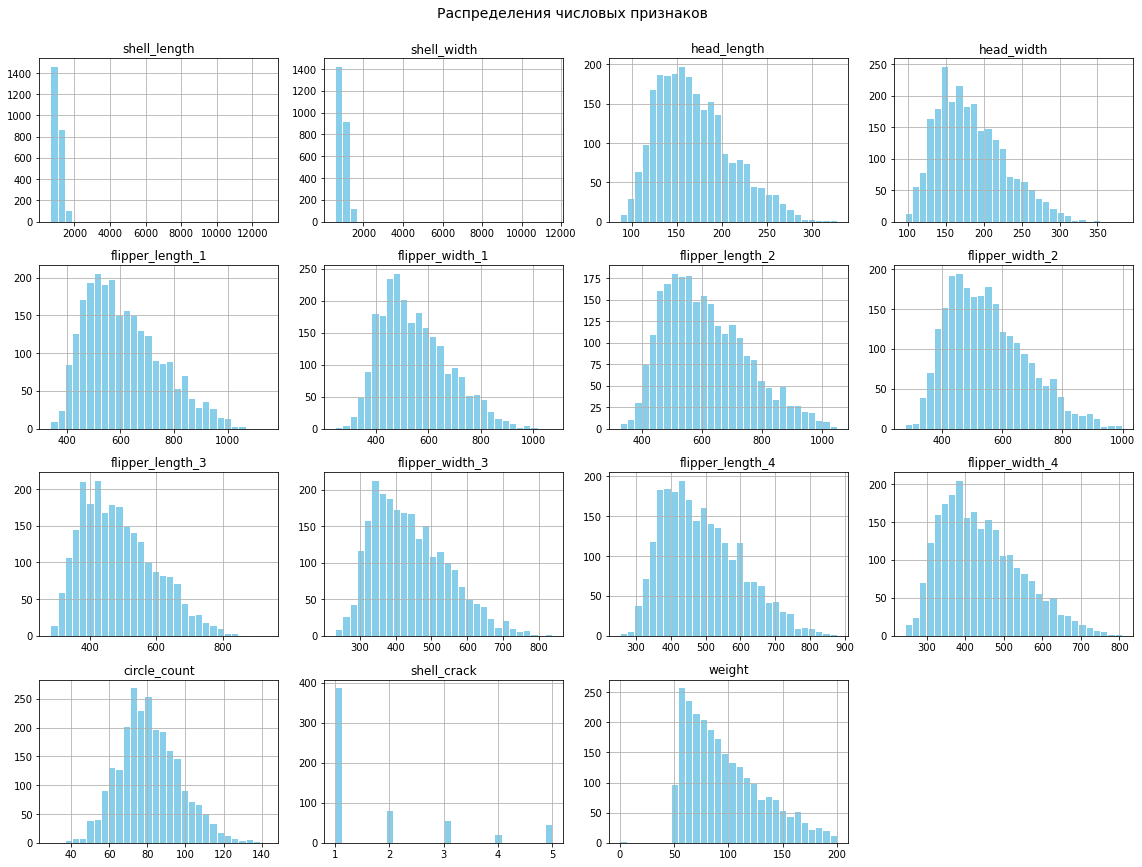

In [194]:
cm_df.hist(figsize=(16, 12), bins=30, color='skyblue', edgecolor='white')
plt.suptitle('Распределения числовых признаков', y=1, fontsize=14)
plt.tight_layout()
plt.show()

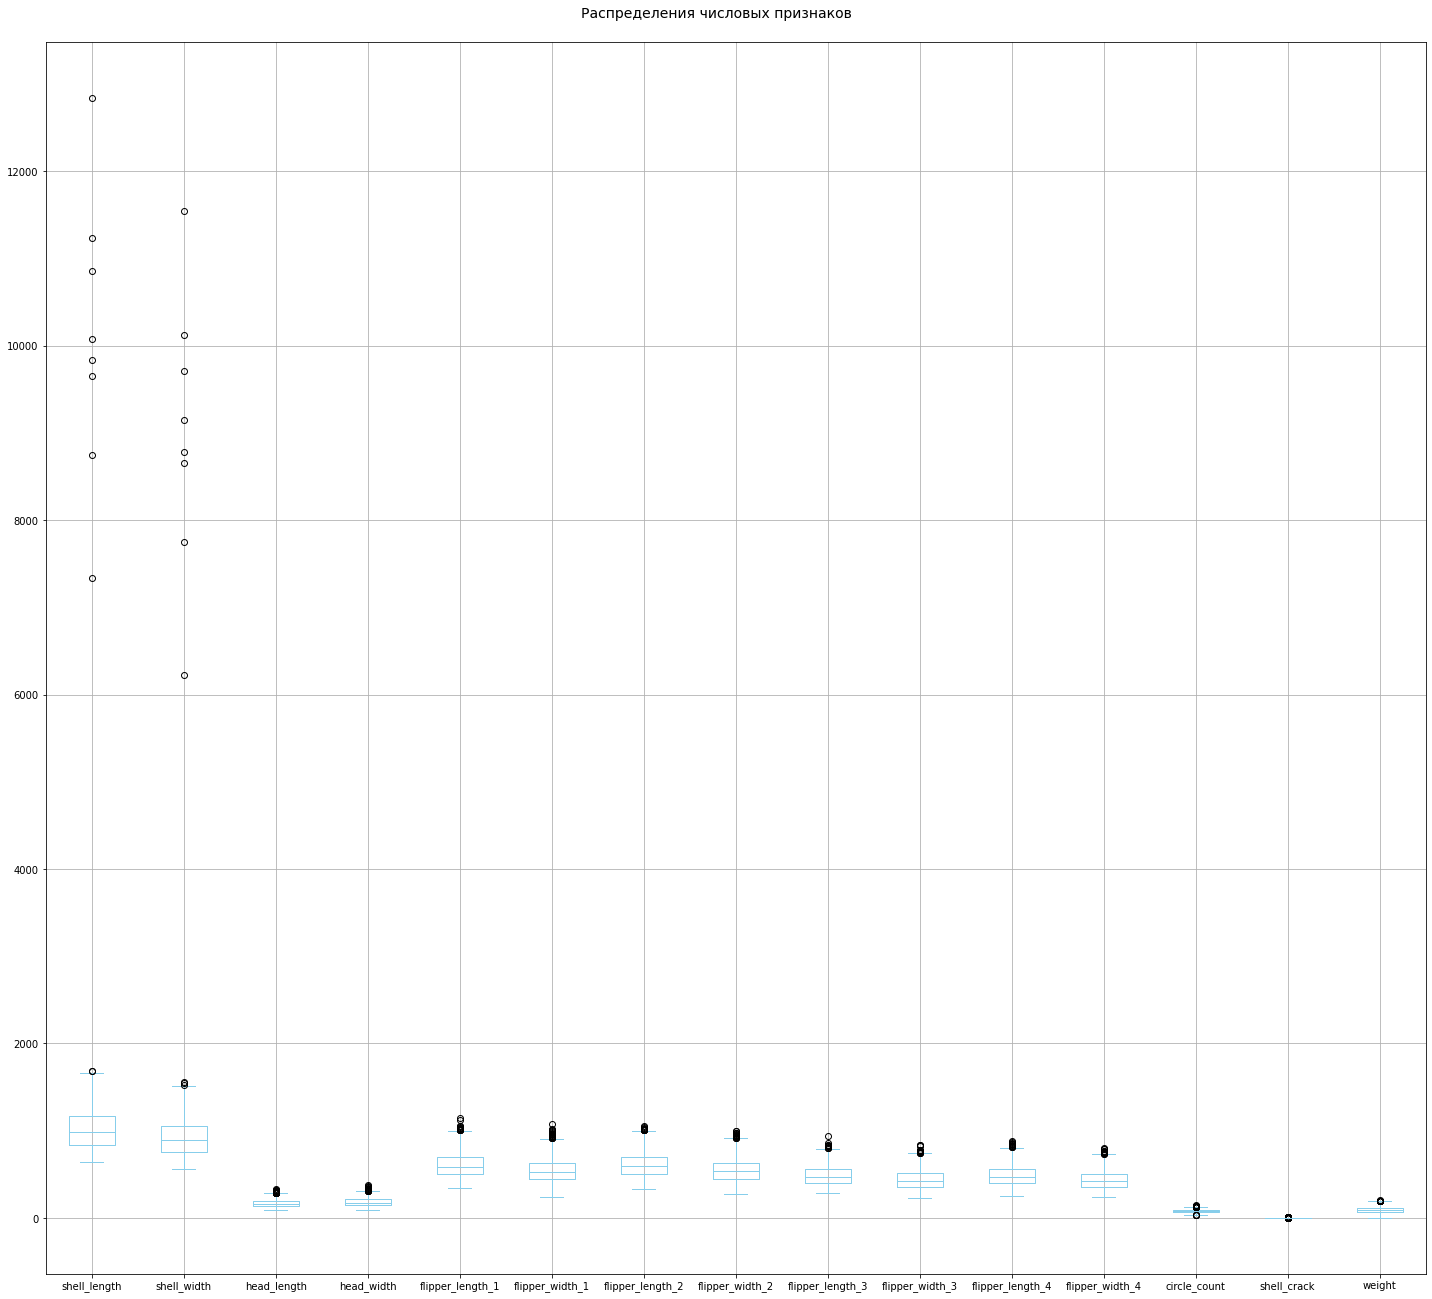

In [195]:
cm_df.boxplot(figsize=(20, 18), color='skyblue')
plt.suptitle('Распределения числовых признаков', y=1, fontsize=14)
plt.tight_layout()
plt.show()

В столбцах shell_length и shell_width наблюдаются аномалии. Если небольшие отклонения от верхней и нижней границ имеют место быть, то значения, которые превышают 6000мм , вероятно, это и есть те данные габаритов, которые волонтёр умножил на 10. Обработаем их

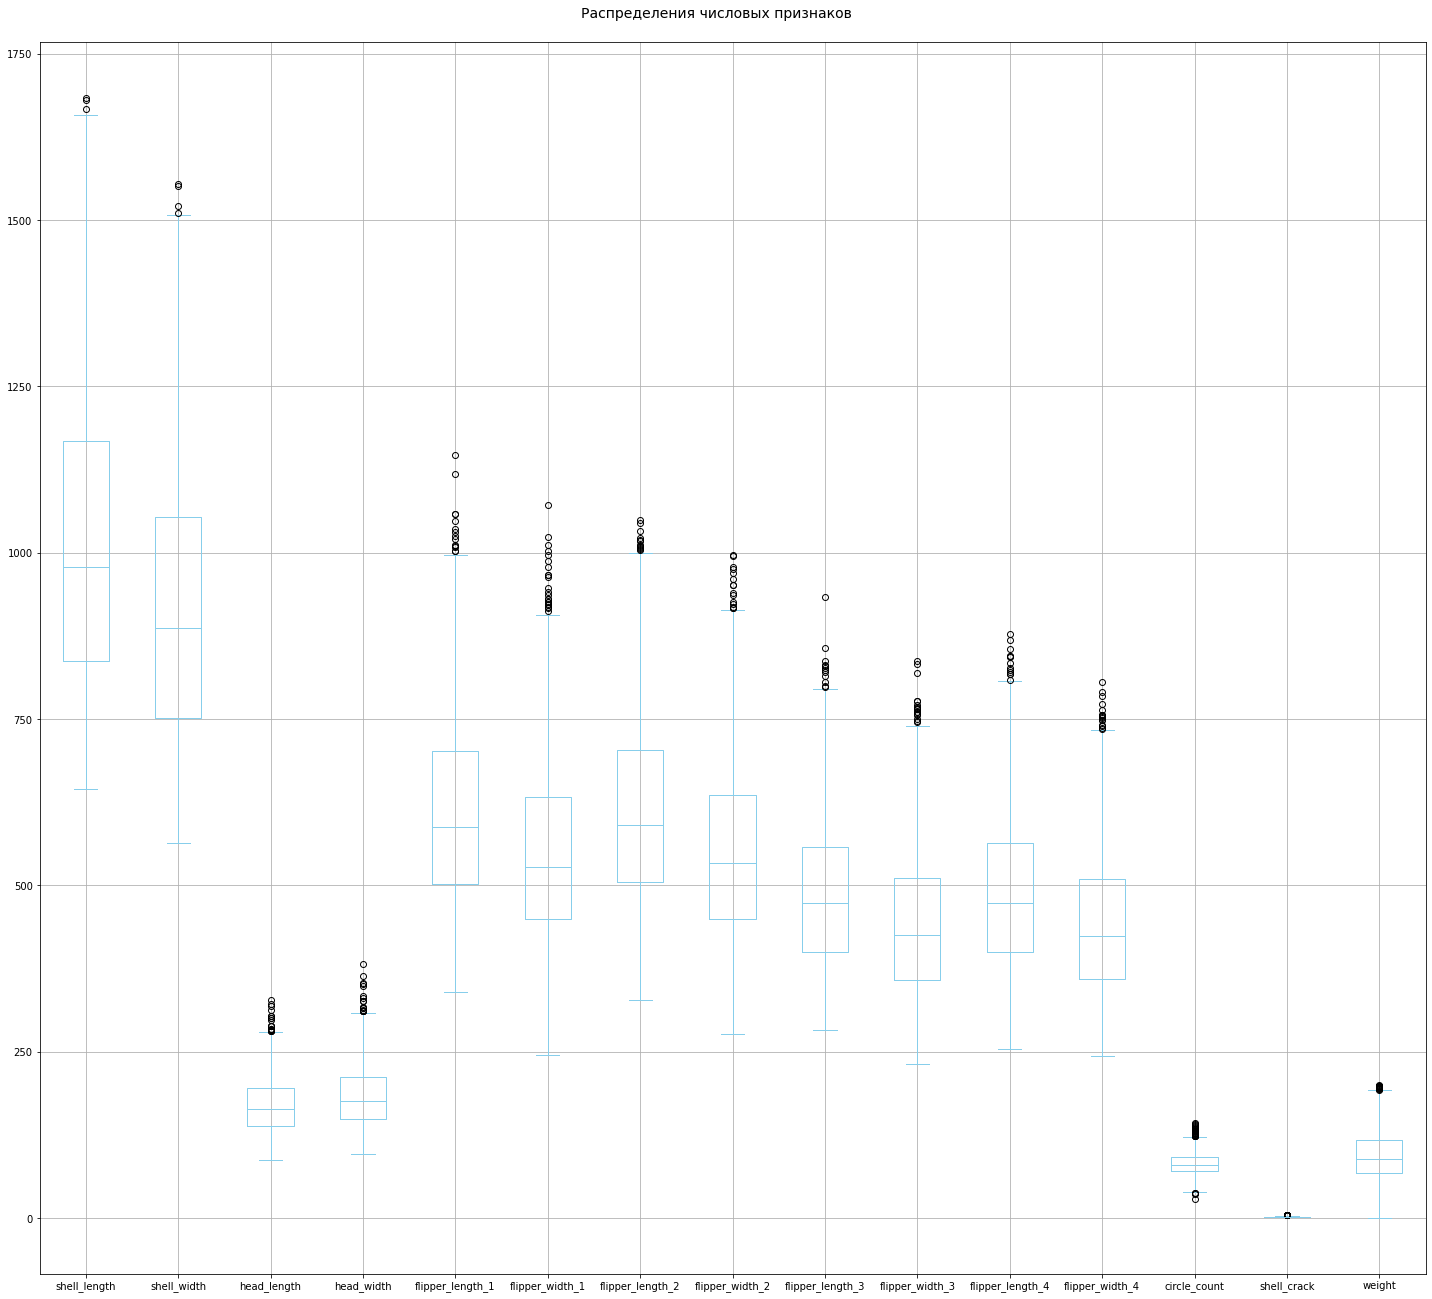

In [196]:
def selection(col):  
    if col > 6000:
        return col/10
    return col

cm_df['shell_length'] = cm_df['shell_length'].apply(selection)
cm_df['shell_width'] = cm_df['shell_width'].apply(selection)

cm_df.boxplot(figsize=(20, 18), color='skyblue')
plt.suptitle('Распределения числовых признаков', y=1, fontsize=14)
plt.tight_layout()
plt.show()

Аномалии устранены

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍  Абсолютно верно.



### Проверяем масштаб признаков

Сравним максимальное и минимальные значения в датафрейме

In [197]:
cm_df.max().max() / cm_df.min()

shell_length           2.609302
shell_width            2.984043
head_length           19.344828
head_width            17.531250
flipper_length_1       4.964602
flipper_width_1        6.869388
flipper_length_2       5.146789
flipper_width_2        6.097826
flipper_length_3       5.968085
flipper_width_3        7.285714
flipper_length_4       6.625984
flipper_width_4        6.925926
circle_count          58.034483
shell_crack         1683.000000
weight                      inf
dtype: float64

Масштаб различается в более чем 1000 раз, это весомо, необходимо проводить стандартизацию, так как у нас много выбросов.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Потребуется масштабирование.


### Анализируем корреляцию между признаками и целевой переменной

interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack', 'weight']
                    weight
weight            1.000000
shell_length      0.891067
shell_width       0.849007
flipper_length_1  0.784163
flipper_length_3  0.764920
flipper_length_4  0.764591
flipper_length_2  0.763559
flipper_width_4   0.746443
flipper_width_2   0.745836
flipper_width_3   0.740223
flipper_width_1   0.735622
head_length       0.709513
head_width        0.696157
shell_crack       0.419761
circle_count      0.392878


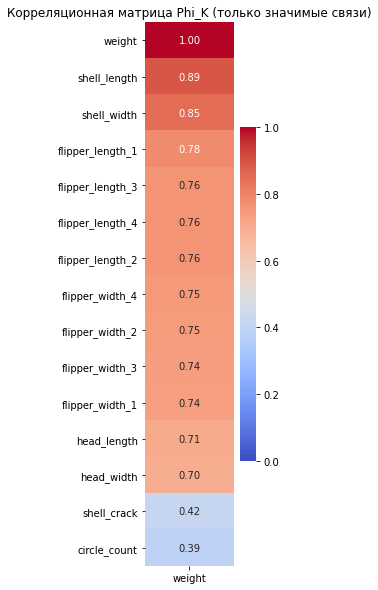

In [198]:
correlations_with_target = cm_df.phik_matrix()[['weight']].sort_values(by='weight', ascending=False)
print(correlations_with_target)
plt.figure(figsize=(2, 10))
sns.heatmap(correlations_with_target, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Корреляционная матрица Phi_K (только значимые связи)')
plt.show()

Наибольшее значение имеют габариты панциря, следом по значимости длина и ширина ласт, с небольшим отставанием - габариты головы. Наименее значимые признаки: Наличие трещин и количество колец. Тем не менее, мы не можем сказать, что какой-либо из признаков нужно выкинуть. 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Все так, низкая корреляция не означает на 100%, что признак лишний.

### Проверяем данные на мультиколлинеарность

In [199]:
def check_collinearity(df, threshold=0.8, target_col=None):
    """
    Находит сильно коррелирующие пары признаков
    threshold - порог корреляции 
    """
    if target_col and target_col in df.columns:
        X = df.drop(columns=[target_col])
    else:
        X = df.copy()
    
    corr_matrix = X.corr()
    
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    return pd.DataFrame(high_corr).sort_values('correlation', ascending=False)

collinear_pairs = check_collinearity(cm_df, threshold=0.8, target_col='weight')
print(collinear_pairs)


            feature1          feature2  correlation
0       shell_length       shell_width     0.959996
3       shell_length  flipper_length_1     0.920130
9       shell_length  flipper_length_4     0.918971
5       shell_length  flipper_length_2     0.917355
7       shell_length  flipper_length_3     0.915656
15       shell_width  flipper_length_2     0.905552
13       shell_width  flipper_length_1     0.904319
19       shell_width  flipper_length_4     0.902691
17       shell_width  flipper_length_3     0.901921
6       shell_length   flipper_width_2     0.897790
10      shell_length   flipper_width_4     0.895541
8       shell_length   flipper_width_3     0.895208
4       shell_length   flipper_width_1     0.891002
16       shell_width   flipper_width_2     0.884741
20       shell_width   flipper_width_4     0.884262
18       shell_width   flipper_width_3     0.880794
14       shell_width   flipper_width_1     0.876345
31  flipper_length_1  flipper_length_2     0.869475
1       shel

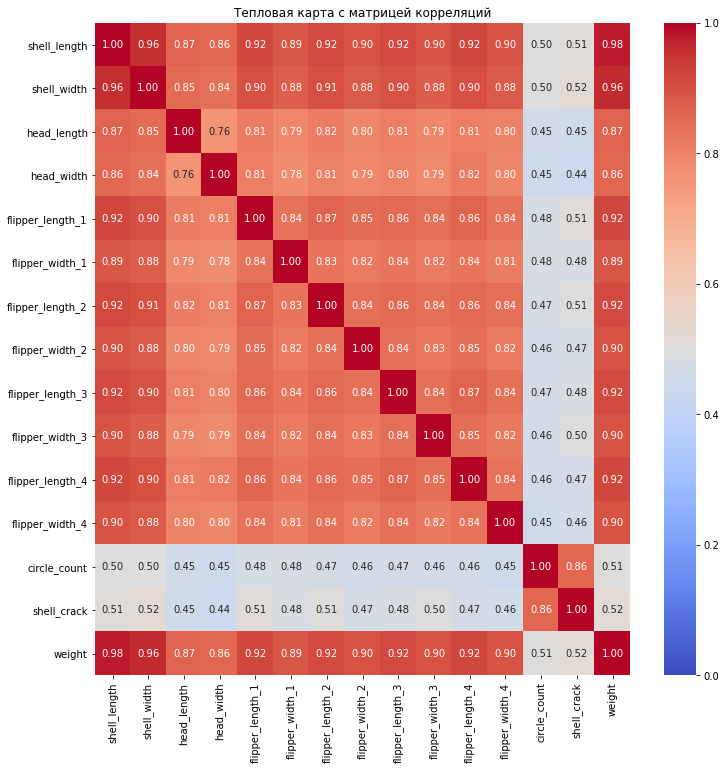

In [200]:
corr_matrix = cm_df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Тепловая карта с матрицей корреляций')
plt.show()


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Гораздо гораздо удобнее нарисовать тепловую карту с матрицей корреляций.

<br/>
<div class="alerфt alert-info">
         Тепловая карта с матрицей корреляций теперь нарисована
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера #2 <a class="tocSkip"> </h2>
    
👍 Отлично. Выше можно чуть уменьшить размер графиков с аномалиями, чтобы все графики в проекте были примерно единого размера. Это тоже влияет на удобство чтения.
  

Коррелирующих признаков очень много, как правило признаки, связанные с одним органом (голова или ласты с одной стороны) сильно коррелируют между собой. Для обработки можно объединить коррелирующие признаки, например, найдя среднее значение. Но, также разумным решением будет оставить всё как есть и применить регуляризацию.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Хорошее предложение. Можем построить модель с признаками как есть, затем со средним от скоррелированных пар, посмотрим, как поменяется качество, какой вариант будет лучше.

Промежуточные выводы:

- Мы привели названия столбцов к корректному виду
- Оптимизировали типы данных
- Провели отбор признаков, оставив только нужный вид черепах
- Устранили 340 дубликатов
- Исправили ошибки волонтёров, связанные с путаницей сантиметров и милиметров
- Выяснили, что в дальнейшем необходима стандартизация
- Проверили данные на корреляцию и сделали выводы о мультиколлинеарности

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Замечательно по оформлению комментариев и выводов.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

### Разделяем данные

In [201]:
def split(df, target_col, train_test = 0.2, train_validation = 0.25):
    """Принимает на вход датасет, название целевой переменной, долю тестовой выборки от всего датасета, долю валидационной выборки от тренеровочной. 
       Возвращает три выборки - тренеровочную, валидационную и тестовую"""
    y = df[target_col]
    X = df.drop(columns=target_col)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = train_test, shuffle=True, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = train_validation, shuffle=True, random_state=42)
    return X_train, y_train, X_val, y_val, X_test, y_test
X_train, y_train, X_val, y_val, X_test, y_test = split(cm_df, 'weight')

### Обрабатываем пропуски

При обработке пропусков в данной ситуации придерживаемся двум правилам: строки с пропусками в целевой переменной удаляем, строки с пропусками в признаках заполняем медианным значением по обучающей выборке

In [202]:
y_train.dropna(inplace = True)
y_val.dropna(inplace = True)  
y_test.dropna(inplace = True)
X = cm_df.drop(columns='weight')
for i in X.columns:
    med = X_train[i].median()
    X_train[i].fillna(med, inplace = True)
    X_val[i].fillna(med, inplace = True)
    X_test[i].fillna(med, inplace = True)

### Создаём функцию для стандартизации признаков

In [203]:
def stand_data(X_train, X_val, X_test):
    """Функция принимает на вход обучающую, валидационную и тестовую выборки. 
    Возвращает стандартизированные выборки""" 
    mean = X_train.mean()
    std = X_train.std()
    X_train_stand = (X_train - mean) / std
    X_val_stand = (X_val - mean) / std
    X_test_stand = (X_test - mean) / std
    return X_train_stand, X_val_stand, X_test_stand

### Создаём функцию для нормализации признаков

In [204]:
def norm_data(X_train, X_val, X_test):
    """Функция принимает на вход обучающую, валидационную и тестовую выборки. 
    Возвращает нормализованные выборки""" 
    min_val = X_train.min()
    max_val = X_train.max()
    X_train_norm = (X_train - min_val) / (max_val - min_val)
    X_val_norm = (X_val - min_val) / (max_val - min_val)
    X_test_norm = (X_test - min_val) / (max_val - min_val)
    return X_train_norm, X_val_norm, X_test_norm

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Все верно, но полезно перепроверить правильность: отмасштабируем данные, посмотрим на среднее и стандартное отклонение.

### Формируем датасеты

In [205]:
X_train_stand, X_val_stand, X_test_stand = stand_data(X_train, X_val, X_test)
X_train_norm, X_val_norm, X_test_norm = norm_data(X_train, X_val, X_test)

datasets = {
    'raw':      (X_train, X_val, X_test),
    'standard': (X_train_stand, X_val_stand, X_test_stand),
    'minmax':   (X_train_norm, X_val_norm, X_test_norm)
}

In [206]:
print('Стандартизация')
pd.DataFrame({'std': X_train_stand.std(), 'mean': abs(round(X_train_stand.mean(), 2))})

Стандартизация


,std,mean
shell_length,1.0,0.0
shell_width,1.0,0.0
head_length,1.0,0.0
head_width,1.0,0.0
flipper_length_1,1.0,0.0
flipper_width_1,1.0,0.0
flipper_length_2,1.0,0.0
flipper_width_2,1.0,0.0
flipper_length_3,1.0,0.0
flipper_width_3,1.0,0.0


In [207]:
print('Нормализация')
pd.DataFrame({'std': round(X_train_norm.std(), 2), 'mean': round(X_train_norm.mean(), 2)})

Нормализация


,std,mean
shell_length,0.23,0.37
shell_width,0.21,0.36
head_length,0.18,0.36
head_width,0.17,0.34
flipper_length_1,0.18,0.34
flipper_width_1,0.16,0.37
flipper_length_2,0.19,0.40
flipper_width_2,0.18,0.38
flipper_length_3,0.17,0.30
flipper_width_3,0.17,0.34


<br/>
<div class="alerфt alert-info">
         Данные проверены
</div>

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

In [208]:
data = {'Название модели': [],
'Название датасета': [],
'MAE': [],
'MSE': [], 
'R²': [],
'MAPE': []
       }

df = pd.DataFrame(data)

Вспомогательные функции

In [209]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return round(mae, 3), round(mse, 3), round(mape, 3), round(r2, 3)

### Строим базовую модель

In [210]:
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)
y_dummy_pred = dummy_regr.predict(X_train)
mae, mse, mape, r2 = calculate_metrics(y_train, y_dummy_pred)
new_row = {'Название модели': 'DummyRegressor', 'Название датасета': 'raw', 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
df = df.append(new_row, ignore_index=True)
print(df)

  Название модели Название датасета        MAE          MSE   R²          MAPE
0  DummyRegressor               raw  28.599001  1226.911011  0.0  5.829122e+14


Как и ожидалось, базовая модель никак не может обобщить данные, поэтому никак их не объясняет. лосс слишком большой, такая модель нам не подходит.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Здесь мало что можно прокомментировать, однако лучше и здесь в паре строк описать, какое качество получили.

### Обучаем модели

Обучаем LinearRegression на разных датасетах

In [211]:
lin_regr_raw = LinearRegression()
lin_regr_raw.fit(X_train, y_train)
y_lin_regr_raw = lin_regr_raw.predict(X_train)
mae, mse, mape, r2 = calculate_metrics(y_train, y_lin_regr_raw)
new_row = {'Название модели': 'LinearRegression', 'Название датасета': 'raw', 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
df = df.append(new_row, ignore_index=True)

lin_regr_stand = LinearRegression()
lin_regr_stand.fit(X_train_stand, y_train)
y_lin_regr_stand = lin_regr_stand.predict(X_train_stand)
mae, mse, mape, r2 = calculate_metrics(y_train, y_lin_regr_stand)
new_row = {'Название модели': 'LinearRegression', 'Название датасета': 'standard', 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
df = df.append(new_row, ignore_index=True)

lin_regr_norm = LinearRegression()
lin_regr_norm.fit(X_train_norm, y_train)
y_lin_regr_norm = lin_regr_norm.predict(X_train_norm)
mae, mse, mape, r2 = calculate_metrics(y_train, y_lin_regr_norm)
new_row = {'Название модели': 'LinearRegression', 'Название датасета': 'minmax', 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
df = df.append(new_row, ignore_index=True)
print(df)

    Название модели Название датасета        MAE          MSE     R²  \
0    DummyRegressor               raw  28.599001  1226.911011  0.000   
1  LinearRegression               raw   3.927000    47.845000  0.961   
2  LinearRegression          standard   3.927000    47.845000  0.961   
3  LinearRegression            minmax   3.927000    47.845000  0.961   

           MAPE  
0  5.829122e+14  
1  7.466734e+14  
2  7.466734e+14  
3  7.466734e+14  


Обучаем Lasso и Ridge на разных датасетах с разным значением alpha

In [212]:
for i in ['raw','standard','minmax']:
    X_train = datasets[i][0]
    for a in [0.01, 0.1, 1, 10, 100]:
        for j in ['Lasso', 'Ridge']:
            if j == 'Lasso':
                model = Lasso(alpha = a)
            else:
                model = Ridge(alpha = a)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_train)
            mae, mse, mape, r2 = calculate_metrics(y_train, y_pred)
            new_row = {'Название модели': f'{j}(alpha = {a})', 'Название датасета': i, 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
            df = df.append(new_row, ignore_index=True)
print(df.sort_values(by = 'MAE'))

        Название модели Название датасета        MAE          MSE     R²  \
26   Lasso(alpha = 0.1)            minmax   3.916000    48.859000  0.960   
16   Lasso(alpha = 0.1)          standard   3.917000    47.864000  0.961   
18     Lasso(alpha = 1)          standard   3.919000    49.283000  0.960   
24  Lasso(alpha = 0.01)            minmax   3.920000    47.857000  0.961   
6    Lasso(alpha = 0.1)               raw   3.926000    47.868000  0.961   
8      Lasso(alpha = 1)               raw   3.926000    47.893000  0.961   
14  Lasso(alpha = 0.01)          standard   3.926000    47.845000  0.961   
25  Ridge(alpha = 0.01)            minmax   3.927000    47.845000  0.961   
19     Ridge(alpha = 1)          standard   3.927000    47.845000  0.961   
17   Ridge(alpha = 0.1)          standard   3.927000    47.845000  0.961   
15  Ridge(alpha = 0.01)          standard   3.927000    47.845000  0.961   
13   Ridge(alpha = 100)               raw   3.927000    47.846000  0.961   
9      Ridge

Обучаем SGDRegressor на разных датасетах с разным значением гиперпараметров

In [213]:

params_1 = {
    'penalty': 'l2',
    'alpha': 0.0001,
    'max_iter': 10000,
    'tol': 1e-4,
    'learning_rate': 'invscaling',
    'eta0': 0.01,
    'power_t': 0.25,
    'early_stopping': True,
    'validation_fraction': 0.1,
    'n_iter_no_change': 10,
    'shuffle': True,
    'random_state': 42
}

params_2 = {
    'epsilon': 0.1,            
    'penalty': 'l2',
    'alpha': 0.001,
    'max_iter': 8000,
    'tol': 1e-4,
    'learning_rate': 'adaptive',
    'eta0': 0.01,
    'early_stopping': True,
    'validation_fraction': 0.1,
    'n_iter_no_change': 5,
    'shuffle': True,
    'random_state': 42
}

params_3 = {
    'penalty': 'elasticnet',
    'alpha': 0.001,
    'l1_ratio': 0.5,           
    'max_iter': 9000,
    'tol': 1e-5,
    'learning_rate': 'constant',
    'eta0': 0.005,
    'early_stopping': False,   
    'shuffle': True,
    'random_state': 42
}

params_4 = {
    'penalty': 'l2',
    'alpha': 0.00001,
    'max_iter': 9000,
    'tol': 1e-6,
    'learning_rate': 'invscaling',
    'eta0': 0.001,
    'power_t': 0.5,
    'early_stopping': False,
    'shuffle': True,
    'random_state': 42
}

all_params = [params_1, params_2, params_3, params_4]
all_params_strings = ['params_1', 'params_2', 'params_3', 'params_4']
loss_list = ['squared_loss', 'huber', 'epsilon_insensitive']

X_train_stand = datasets['standard'][0]
X_train_norm = datasets['minmax'][0]

def learn_SGDR(name, loss, X_train, y_train=y_train):
    global df
    for a, a_str in zip(all_params, all_params_strings):
        model = SGDRegressor(loss = loss, **a)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        mae, mse, mape, r2 = calculate_metrics(y_train, y_pred)
        new_row = {'Название модели': f'SGDRegressor(loss={loss}, {a_str})', 'Название датасета': i, 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
        df = df.append(new_row, ignore_index=True)

In [214]:
learn_SGDR(name = 'standard', loss = loss_list[0], X_train = X_train_stand)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "


In [215]:
learn_SGDR(name = 'standard', loss = loss_list[1], X_train = X_train_stand)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "


In [216]:
learn_SGDR(name = 'standard', loss = loss_list[2], X_train = X_train_stand)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "


In [217]:
df.sort_values(by = 'MAE')

,Название модели,Название датасета,MAE,MSE,R²,MAPE
44,"SGDRegressor(loss=epsilon_insensitive, params_3)",minmax,3.850000,48.667000,0.960,7.477171e+14
43,"SGDRegressor(loss=epsilon_insensitive, params_2)",minmax,3.900000,48.950000,0.960,7.464374e+14
26,Lasso(alpha = 0.1),minmax,3.916000,48.859000,0.960,7.441993e+14
16,Lasso(alpha = 0.1),standard,3.917000,47.864000,0.961,7.463140e+14
18,Lasso(alpha = 1),standard,3.919000,49.283000,0.960,7.417804e+14
24,Lasso(alpha = 0.01),minmax,3.920000,47.857000,0.961,7.464167e+14
42,"SGDRegressor(loss=epsilon_insensitive, params_1)",minmax,3.924000,49.212000,0.960,7.464583e+14
8,Lasso(alpha = 1),raw,3.926000,47.893000,0.961,7.474773e+14
14,Lasso(alpha = 0.01),standard,3.926000,47.845000,0.961,7.466436e+14
6,Lasso(alpha = 0.1),raw,3.926000,47.868000,0.961,7.473816e+14


In [218]:
learn_SGDR(name = 'minmax', loss = loss_list[0], X_train = X_train_norm)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "


In [219]:
learn_SGDR(name = 'minmax', loss = loss_list[1], X_train = X_train_norm)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "


In [220]:
learn_SGDR(name = 'minmax', loss = loss_list[2], X_train = X_train_norm)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "


In [221]:
df.sort_values(by = 'MAE')

,Название модели,Название датасета,MAE,MSE,R²,MAPE
44,"SGDRegressor(loss=epsilon_insensitive, params_3)",minmax,3.850000,48.667000,0.960,7.477171e+14
43,"SGDRegressor(loss=epsilon_insensitive, params_2)",minmax,3.900000,48.950000,0.960,7.464374e+14
26,Lasso(alpha = 0.1),minmax,3.916000,48.859000,0.960,7.441993e+14
16,Lasso(alpha = 0.1),standard,3.917000,47.864000,0.961,7.463140e+14
18,Lasso(alpha = 1),standard,3.919000,49.283000,0.960,7.417804e+14
24,Lasso(alpha = 0.01),minmax,3.920000,47.857000,0.961,7.464167e+14
42,"SGDRegressor(loss=epsilon_insensitive, params_1)",minmax,3.924000,49.212000,0.960,7.464583e+14
6,Lasso(alpha = 0.1),raw,3.926000,47.868000,0.961,7.473816e+14
8,Lasso(alpha = 1),raw,3.926000,47.893000,0.961,7.474773e+14
14,Lasso(alpha = 0.01),standard,3.926000,47.845000,0.961,7.466436e+14


Промежуточные выводы
- Нам удалось обучить 58 моделей: 1 Dummy, 3 Linear, 15 Lasso, 15 Ridge, 24 SGD
- В топ 10 вошли 7 Lasso и 3 SGD
- Лучшей моделью по MAE стала SGDRegressor(loss=epsilon_insensitive, params_3)
- По первому условию в МАE <= 5 По тренеровочной выборке у нас проходят все модели из топ 10
- По условию в коэфф. детерминации >= 0.97 не проходит ни одна модель

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

In [222]:
data = {'Название модели': [],
'Название датасета': [],
'MAE train': [],
'R² train': [], 
'MAE val': [],
'R² val': [],
'Изменение MAE': [],
'Изменение R²': []     
       }

df_val = pd.DataFrame(data)

In [223]:
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)
y_dummy_pred = dummy_regr.predict(X_train)
mae_train, mse, mape, r2_train = calculate_metrics(y_train, y_dummy_pred)
y_dummy_pred = dummy_regr.predict(X_val)
mae_val, mse, mape, r2_val = calculate_metrics(y_val, y_dummy_pred)
new_row = {
    'Название модели': 'DummyRegressor',
    'Название датасета': 'raw',
    'MAE train': mae_train,
    'R² train': r2_train,     
    'MAE val': mae_val,
    'R² val': r2_val,
    'Изменение MAE': ((mae_val - mae_train) / mae_train * 100),
    'Изменение R²': r2_val - r2_train
}
df_val = df_val.append(new_row, ignore_index=True)
print(df_val)

  Название модели Название датасета  MAE train  R² train  MAE val  R² val  \
0  DummyRegressor               raw  28.599001       0.0   29.584  -0.003   

   Изменение MAE  Изменение R²  
0       3.444172        -0.003  


Не удалось существенно улучшить результат базовой модели, более того, она показала ухудшение качества, это было ожидаемо

In [224]:
lin_regr_raw = LinearRegression()
lin_regr_raw.fit(X_train, y_train)
y_lin_regr_raw = lin_regr_raw.predict(X_train)
mae_train, mse, mape, r2_train = calculate_metrics(y_train, y_lin_regr_raw)
y_lin_regr_raw = lin_regr_raw.predict(X_val)
mae_val, mse, mape, r2_val = calculate_metrics(y_val, y_lin_regr_raw)
new_row = {
    'Название модели': 'LinearRegressor',
    'Название датасета': 'raw',
    'MAE train': mae_train,
    'R² train': r2_train,     
    'MAE val': mae_val,
    'R² val': r2_val,
    'Изменение MAE': ((mae_val - mae_train) / mae_train * 100),
    'Изменение R²': r2_val - r2_train
}
df_val = df_val.append(new_row, ignore_index=True)

lin_regr_stand = LinearRegression()
lin_regr_stand.fit(X_train_stand, y_train)
y_lin_regr_stand = lin_regr_stand.predict(X_train_stand)
mae_train, mse, mape, r2_train = calculate_metrics(y_train, y_lin_regr_stand)
y_lin_regr_stand = lin_regr_stand.predict(X_val_stand)
mae_val, mse, mape, r2_val = calculate_metrics(y_val, y_lin_regr_stand)
new_row = {
    'Название модели': 'LinearRegressor',
    'Название датасета': 'standard',
    'MAE train': mae_train,
    'R² train': r2_train,     
    'MAE val': mae_val,
    'R² val': r2_val,
    'Изменение MAE': ((mae_val - mae_train) / mae_train * 100),
    'Изменение R²': r2_val - r2_train
}
df_val = df_val.append(new_row, ignore_index=True)

lin_regr_norm = LinearRegression()
lin_regr_norm.fit(X_train_norm, y_train)
y_lin_regr_norm = lin_regr_norm.predict(X_train_norm)
mae_train, mse, mape, r2_train = calculate_metrics(y_train, y_lin_regr_norm)
y_lin_regr_norm = lin_regr_norm.predict(X_val_norm)
mae_val, mse, mape, r2_val = calculate_metrics(y_val, y_lin_regr_norm)
new_row = {
    'Название модели': 'LinearRegressor',
    'Название датасета': 'minmax',
    'MAE train': mae_train,
    'R² train': r2_train,     
    'MAE val': mae_val,
    'R² val': r2_val,
    'Изменение MAE': ((mae_val - mae_train) / mae_train * 100),
    'Изменение R²': r2_val - r2_train
}
df_val = df_val.append(new_row, ignore_index=True)
print(df_val)

   Название модели Название датасета  MAE train  R² train     MAE val  \
0   DummyRegressor               raw  28.599001     0.000      29.584   
1  LinearRegressor               raw   3.927000     0.961  125956.636   
2  LinearRegressor          standard   3.927000     0.961       3.795   
3  LinearRegressor            minmax   3.927000     0.961       3.795   

         R² val  Изменение MAE  Изменение R²  
0 -3.000000e-03   3.444172e+00 -3.000000e-03  
1 -1.329548e+07   3.207352e+06 -1.329548e+07  
2  9.740000e-01  -3.361345e+00  1.300000e-02  
3  9.740000e-01  -3.361345e+00  1.300000e-02  


In [225]:
for i in ['raw','standard','minmax']:
    X_train = datasets[i][0]
    X_val = datasets[i][1]
    for a in [0.01, 0.1, 1, 10, 100]:
        for j in ['Lasso', 'Ridge']:
            if j == 'Lasso':
                model = Lasso(alpha = a)
            else:
                model = Ridge(alpha = a)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_train)
            mae_train, mse, mape, r2_train = calculate_metrics(y_train, y_pred)
            y_pred = model.predict(X_val)
            mae_val, mse, mape, r2_val = calculate_metrics(y_val, y_pred)
            new_row = {
                'Название модели': f'{j}(alpha = {a})',
                'Название датасета': i,
                'MAE train': mae_train,
                'R² train': r2_train,     
                'MAE val': mae_val,
                'R² val': r2_val,
                'Изменение MAE': ((mae_val - mae_train) / mae_train * 100),
                'Изменение R²': r2_val - r2_train
            }
            df_val = df_val.append(new_row, ignore_index=True)
print(df_val.sort_values(by = 'MAE val'))

        Название модели Название датасета  MAE train  R² train     MAE val  \
16   Lasso(alpha = 0.1)          standard   3.917000     0.961       3.783   
8      Lasso(alpha = 1)               raw   3.926000     0.961       3.783   
6    Lasso(alpha = 0.1)               raw   3.926000     0.961       3.785   
29     Ridge(alpha = 1)            minmax   3.935000     0.961       3.790   
24  Lasso(alpha = 0.01)            minmax   3.920000     0.961       3.790   
27   Ridge(alpha = 0.1)            minmax   3.927000     0.961       3.793   
13   Ridge(alpha = 100)               raw   3.927000     0.961       3.793   
21    Ridge(alpha = 10)          standard   3.934000     0.961       3.794   
19     Ridge(alpha = 1)          standard   3.927000     0.961       3.794   
4   Lasso(alpha = 0.01)               raw   3.927000     0.961       3.794   
14  Lasso(alpha = 0.01)          standard   3.926000     0.961       3.794   
11    Ridge(alpha = 10)               raw   3.927000     0.961  

In [226]:
def learn_SGDR_val(name, loss, X_train, X_val, y_train = y_train, y_val = y_val):
    global df_val
    for a, a_str in zip(all_params, all_params_strings):
        model = SGDRegressor(loss = loss, **a)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        mae_train, mse, mape, r2_train = calculate_metrics(y_train, y_pred)
        y_pred = model.predict(X_val)
        mae_val, mse, mape, r2_val = calculate_metrics(y_val, y_pred)
        new_row = {
            'Название модели': f'SGDRegressor(loss={j}, {a_str})',
            'Название датасета': i,
            'MAE train': mae_train,
            'R² train': r2_train,     
            'MAE val': mae_val,
            'R² val': r2_val,
            'Изменение MAE': ((mae_val - mae_train) / mae_train * 100),
            'Изменение R²': r2_val - r2_train
        }
        df_val = df_val.append(new_row, ignore_index=True)

In [227]:
for i in ['standard','minmax']:
    X_train = datasets[i][0]
    X_val = datasets[i][1]
    for j in loss_list:
        learn_SGDR_val(name = i, loss = j, X_train=X_train, X_val=X_val)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Con

In [228]:
print(df_val.sort_values(by = 'MAE val'))

                                     Название модели Название датасета  \
44  SGDRegressor(loss=epsilon_insensitive, params_3)          standard   
43  SGDRegressor(loss=epsilon_insensitive, params_2)          standard   
42  SGDRegressor(loss=epsilon_insensitive, params_1)          standard   
16                                Lasso(alpha = 0.1)          standard   
8                                   Lasso(alpha = 1)               raw   
6                                 Lasso(alpha = 0.1)               raw   
29                                  Ridge(alpha = 1)            minmax   
24                               Lasso(alpha = 0.01)            minmax   
35         SGDRegressor(loss=squared_loss, params_2)          standard   
27                                Ridge(alpha = 0.1)            minmax   
13                                Ridge(alpha = 100)               raw   
4                                Lasso(alpha = 0.01)               raw   
11                                 Rid

Лучшей моделью по MAE на валидационной выборке стала модель Стохастической регрессии на стандартизированных данных с набором гиперпараметров 3 и лоссом epsilon_insensitive. Она успешно прошла все тесты: MAE = 3.718 < 5, R² = 0.974 > 0.97. Модель не показала признаков переобучения, улучшив качество предсказания на валидационной выборке.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 В этой части все отлично. Результат сначала оказался ниже ожидаемого, но ты решил не сдаваться и перепробовал много моделей и гиперпараметров.
    
    
Иногда, если качество низкое, но ожидаем выше, можем просто поменять random_state. Возможно, в валидацию попали неудобные для модели строки. Можем вывести строки по размеру ошибки, посмотреть, есть ли системность в ошибках. Отдельно можем вывести «остатки модели» - рассогласование (разность) между предсказанием и реальным значением, построить гистограмму остатков, проверить, нормально ли они распределены, построить скаттерплот, также исследовать на предмет наличия структуры.
    
В целом, если не используем кросс-валидацию, полезно сделать пару запусков с разным random_state, чтобы убедиться в стабильности качества модели.
    
Итого: перепроверим, это модель что-то недоучила в данных или данные сложные. Если проблема в данных, проверим, это системный мусор или мы что-то недообработали. Если в модели - можем ли мы сделать такие модификации признаков, которые помогли бы модели лучше усвоить заложенные закономерности.

<br/>
<div class="alerфt alert-info">
         Попробовал поменять random_state на 1 и 99. Результат почти не поменялся.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера #2 <a class="tocSkip"> </h2>
    
👍 Ок, это не гарантированное поведение модели, что результат должен был поменяться. Просто это один из удобных инструментов перепроверить стабильность. Ну и плюс изменение random_state не гарантирует, что токсичная строка теперь точно попадет в другую выборку и мы увидем изменение, это тоже нужно понимать, здесь стоит попробовать несколько вариантов. 
  

Среднее остатков: 0.0532
Стандартное отклонение остатков: 7.1565
MSE: 51.2183


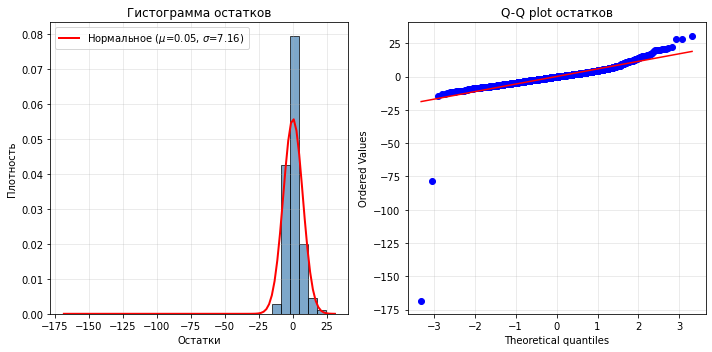

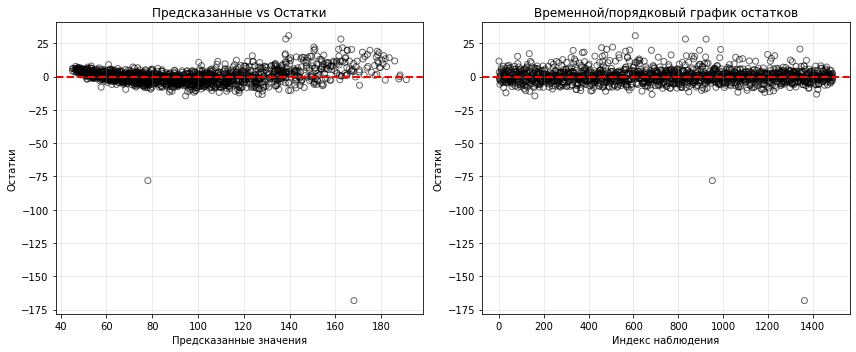

In [229]:
model = SGDRegressor(loss='epsilon_insensitive', **params_3)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
residuals = y_train - y_pred

print(f"Среднее остатков: {np.mean(residuals):.4f}")
print(f"Стандартное отклонение остатков: {np.std(residuals):.4f}")
print(f"MSE: {mean_squared_error(y_train, y_pred):.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
count, bins, _ = plt.hist(residuals, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# Подгоняем нормальное распределение
mu, std = np.mean(residuals), np.std(residuals)
x_norm = np.linspace(min(residuals), max(residuals), 100)
pdf_norm = stats.norm.pdf(x_norm, mu, std)
plt.plot(x_norm, pdf_norm, 'r-', linewidth=2, label=f'Нормальное ($\mu$={mu:.2f}, $\sigma$={std:.2f})')
plt.xlabel('Остатки')
plt.ylabel('Плотность')
plt.title('Гистограмма остатков')
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q plot остатков')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Предсказанные значения vs остатки
axes[0].scatter(y_pred, residuals, alpha=0.6, edgecolors='k', facecolors='none')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Предсказанные значения')
axes[0].set_ylabel('Остатки')
axes[0].set_title('Предсказанные vs Остатки')
axes[0].grid(alpha=0.3)

# (b) Порядок наблюдений vs остатки
axes[1].scatter(range(len(residuals)), residuals, alpha=0.6, edgecolors='k', facecolors='none')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Индекс наблюдения')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Временной/порядковый график остатков')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Качество данных очень хорошее, наблюдаются единичные выбросы, которые, возможно, и стали причиной недобора по метрике R^2

Попробуем создать новые признаки: например, среднюю длину и ширину ласты

In [230]:
data = {'Название модели': [],
'Название датасета': [],
'MAE': [],
'MSE': [], 
'R²': [],
'MAPE': []
       }

df_1 = pd.DataFrame(data) 

X_train_1, X_val_1, X_test_1 = X_train, X_val, X_test

for i in (X_train_1, X_val_1, X_test_1):
    i['flipper_length'] = (i['flipper_length_1'] + i['flipper_length_2'] + i['flipper_length_3'] + i['flipper_length_4']) / 4
    i['flipper_width'] = (i['flipper_width_1'] + i['flipper_width_2'] + i['flipper_width_3'] + i['flipper_width_4']) / 4
    i.drop(columns = ['flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4'], inplace = True)

X_train_stand_1, X_val_stand_1, X_test_stand_1 = stand_data(X_train_1, X_val_1, X_test_1)
X_train_norm_1, X_val_norm_1, X_test_norm_1 = norm_data(X_train_1, X_val_1, X_test_1)

datasets_1 = {
    'raw':      (X_train_1, X_val_1, X_test_1),
    'standard': (X_train_stand_1, X_val_stand_1, X_test_stand_1),
    'minmax':   (X_train_norm_1, X_val_norm_1, X_test_norm_1)
}

for i in ['raw','standard','minmax']:
    X_train = datasets_1[i][0]
    for a in [0.01, 0.1, 1, 10, 100]:
        for j in ['Lasso', 'Ridge']:
            if j == 'Lasso':
                model = Lasso(alpha = a)
            else:
                model = Ridge(alpha = a)
            model.fit(X_train_1, y_train)
            y_pred = model.predict(X_train_1)
            mae, mse, mape, r2 = calculate_metrics(y_train, y_pred)
            new_row = {'Название модели': f'{j}(alpha = {a})', 'Название датасета': i, 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
            df_1 = df_1.append(new_row, ignore_index=True)

def learn_SGDR_val_1(name, loss, X_train, y_train = y_train):
    global df_1
    for a, a_str in zip(all_params, all_params_strings):
        model = SGDRegressor(loss = loss, **a)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        mae, mse, mape, r2 = calculate_metrics(y_train, y_pred)
        new_row = {'Название модели': f'SGDRegressor(loss={j}, {a_str})', 'Название датасета': i, 'MAE': mae, 'MSE': mse, 'R²': r2, 'MAPE': mape}
        df_1 = df_1.append(new_row, ignore_index=True)
        
for i in ['standard','minmax']:
    X_train = datasets_1[i][0]
    X_val = datasets_1[i][1]
    for j in loss_list:
        learn_SGDR_val_1(name = i, loss = j, X_train=X_train_1)
        
print(df_1.sort_values(by = 'MAE'))

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Con

                                     Название модели Название датасета  \
2                                 Lasso(alpha = 0.1)               raw   
22                                Lasso(alpha = 0.1)            minmax   
12                                Lasso(alpha = 0.1)          standard   
0                                Lasso(alpha = 0.01)               raw   
20                               Lasso(alpha = 0.01)            minmax   
10                               Lasso(alpha = 0.01)          standard   
25                                  Ridge(alpha = 1)            minmax   
5                                   Ridge(alpha = 1)               raw   
15                                  Ridge(alpha = 1)          standard   
3                                 Ridge(alpha = 0.1)               raw   
23                                Ridge(alpha = 0.1)            minmax   
13                                Ridge(alpha = 0.1)          standard   
21                               Ridge

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "


С помощью добавления новых признаков и замены ими старых удалось улучшить качество некоторых моделей, хотя и большинство практически не изменилось, и R^2 всё ещё меньше 0.97. 

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [231]:
best_model = SGDRegressor(loss = 'epsilon_insensitive', **params_3)
best_model.fit(X_train_stand, y_train)
y_best_model = best_model.predict(X_test_stand)
mae, mse, mape, r2 = calculate_metrics(y_test, y_best_model)
print(f'MAE = {mae}', f'MSE = {mse}', f'MAPE = {mape}', f'R^2 = {r2}', sep = ' ||| ')

MAE = 3.869 ||| MSE = 27.859 ||| MAPE = 0.041 ||| R^2 = 0.978


Нет признаков переобучения модели, она показала отличное качество на тестовых данных, значительно улучшив результат предсказания, в сравнении с тренеровочными. R^2 составил 0.978, а MAE - 3.869. Эти характеристики полностью удовлетворяют требованиям заказчика, а значит модель может быть рекомендована к внедрению.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Даже с запасом.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [232]:
coeff_df = pd.DataFrame(best_model.coef_, 
                       index=X.columns, 
                       columns=['Коэффициент'])
display(coeff_df)

,Коэффициент
shell_length,10.313821
shell_width,6.749170
head_length,1.727982
head_width,1.130068
flipper_length_1,2.842077
flipper_width_1,1.959733
flipper_length_2,2.816523
flipper_width_2,1.827771
flipper_length_3,1.693736
flipper_width_3,1.217806



<div class="alert alert-warning">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 


Важно вывести коэффициенты с названиями признаков рядом, в таблице. Без них такая информация очень неудобно читается. Все должно быть удобно, не оставляй информацию с уровнем интерпретируемости перфокарт. У тебя отличный проект, давай сделаем чуть красивее. Например:

```


coeff_df = pd.DataFrame(best_model.coef_, 
                       index=X.columns, 
                       columns=['Коэффициент'])
display(coeff_df)


```

<br/>
<div class="alerфt alert-info">
         Исправлено
</div>

Самыми важными признаками оказались длинна и ширина панциря, это логично, ведь эти признаки сильнее всего коррелировали с весом черепахи. Также довольно значимыми признаками могли стать габариты ласт, но они были практически занулены регуляризацией из-за мультиколлинеарности. Для меня стало неожиданнастью, что габариты головы, несмотря на сильную связь с весом, получили незначительные коэффиценты. 'circle_count' и 'shell_crack' получили самые маленькие коэффиценты, это логично, ведь они были самыми малокоррелирующими признаками.


<div class="alert alert-success">
<h2> Комментарий ревьюера  2<a class="tocSkip"> </h2>

👍 Да, распределение признаков выглядит логичным.


## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [233]:
random_str = datasets['standard'][0].loc[798]
random_y = y_train.loc[798]

def best_model_form(features):
    """Принимает на вход все признаки стандартизированного датасета cm_df и возвращает результат формулы лучшей модели"""
    coef = best_model.coef_
    intercept = best_model.intercept_
    
    prediction = np.dot(coef, features) + intercept
    return float(prediction)


print(best_model_form(random_str))
random_y

167.29360392515719


174.776

<div class="alert alert-warning">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Ух, такой длинный в одну строку код называют «спагетти код», он не видим для читателя (как спагеттизированная материя за горизонтом событий черной дыры). 
    
Если что-то выводим на принт, важно это подписать. 
    
Хорошее решение в коде будет хорошо смотреться только при хорошем оформлении. 
    
***
    
По решению, можем не прописывать коэффициенты явно, а группу операций сложения и умножения заменить на скалярное умножение.
    
```
    
coef = best_model.coef_
intercept = best_model.intercept_
   
    
prediction = np.dot(coef, features) + intercept
return float(prediction)
    
```

<br/>
<div class="alerфt alert-info">
         Исправлено
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера #2 <a class="tocSkip"> </h2>
    
👍 Очень компактно, но при этом наглядно.
  

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

ВЫВОДЫ:
- Мы изучили 58 моделей: 1 Dummy, 3 Linear, 15 Lasso, 15 Ridge, 24 SGD
- Итоговая модель прошла все тесты: MAE = 3.869 < 5, R² = 0.978 > 0.97, а также не показала признаков переобучения.
- Итоговую модель можно рекомендовать к внедрению
- Лучшую способность обработки признаков показали модели стохастической регрессии с функцией потерь epsilon_insensitive. Наборы гиперпараметров 3, 2 и 1 заняли три первых места. 4/5 лучших моделей обучены на стандартизированных данных.
- Наиболее важные признаки для модели - это длина и ширина панциря
- Эту модель вполне можно использовать для обучения и предсказания массы других видов черепах, если количество строк там сопоставимо с количеством черепах вида Chelonia mydas

<div class="alert alert-success">
<h2> Комментарий ревьюера  2<a class="tocSkip"> </h2>

👍 Все супер.

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Это была достаточно объемная работа, требующая нахождения в контексте задачи, применения большого объема новых теоретических знаний.

    
**Отмечу положительные моменты проекта🚀**
    
* Хорошая структура проекта.
* Внимательная предобработка и подготовка признаков.
* Хорошие решения по коду
    
**На что стоит обратить внимание🤔**
    
В желтых комментариях оставил пожелания по улучшению проекта. Работу могу принять уже сейчас, но отправлю на доработку, чтобы иметь возможность дать обратную связь по изменениям.



 
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>



<div style="border:solid Chocolate 2px; padding: 40px">

**Комментарий ко второй проверке**

Спасибо за внимательную доработку. 🤝

    
Если что-то пропустил или остались вопросы, напиши в телеграм @kriill

Желаю удачи в дальнейшей учебе!

</div>
